In [2]:
import yaml
import os
from datetime import datetime
from loguru import logger  
import torch 
import torch.nn as nn 
import pandas as pd
from torchvision import transforms
from tqdm import tqdm
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from src.utils.utils import load_config
from src.data.loader import bigearthnet_loader, bigearthnet_DataModule
from src.utils.torch import seed_everything
from src.model_zoo.models import define_model_, define_model_scratch
from src.metrics.metrics import MultiLabelMetrics
from src.utils.wandb_logger import WandbLogger
from src.loader.reader import Dataset_BigEarthNet, Reader
from src.loader.reader import means_s2, stds_s2, get_list_means_std, get_right_dict

In [3]:
## Load yaml file with configs
config = load_config("src/config/config.yaml")

#bands = config['DATASET']['bands']
sensitivity = config['training']['sensitivity']
logger.info(f"Sensitivity:{sensitivity}")
num_epochs = config['training']['n_epoch']
selected_bands = config['model']['select_bands']
dict_sentinel2_bands =  config['model']['sentinel2_bands']
name_selected_bands = [dict_sentinel2_bands[b] for b in selected_bands]
small_fraction = config['training']['slice_of_training']

2025-08-19 12:57:04.609 | INFO     | __main__:<module>:6 - Sensitivity:0.51


In [7]:
## Build up model by definition 
def reader_(config_dataset, name_selected_bands):
    """ Create a class that handles the retrieval of tif files. 
    """
    reader = Reader(
        root_folder_path=config_dataset["datasets"]["root"],
        metadata_parquet_path = config_dataset["datasets"]["metadata_parquet"]
    )
    return reader 

In [8]:
reader = reader_(config)

2025-08-19 13:00:14.535 | INFO     | src.loader.reader:__init__:169 - Initializing the Reader, structuring the paths and files.
2025-08-19 13:00:14.728 | INFO     | src.loader.reader:parent_folders:223 - Found 115 folders in /root/storage_ds/BigEarthNet-S2
2025-08-19 13:00:20.436 | INFO     | src.loader.reader:_create_lookup_structures:207 - Created lookup structures for 145781 patches
2025-08-19 13:00:20.438 | INFO     | src.loader.reader:__init__:191 - None


Number of parent folders: 115
Number of total patches found it: 549488


In [9]:
reader.metadata_parquet['patch_id'].iloc[:10].values

array(['S2A_MSIL2A_20171121T112351_N9999_R037_T29SND_72_79',
       'S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC_66_01',
       'S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_42_27',
       'S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_60_58',
       'S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_65_23',
       'S2A_MSIL2A_20170704T112111_N9999_R037_T29SND_68_87',
       'S2B_MSIL2A_20180515T112109_N9999_R037_T29SNC_89_85',
       'S2A_MSIL2A_20170704T112111_N9999_R037_T29SND_42_52',
       'S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC_26_70',
       'S2A_MSIL2A_20171221T112501_N9999_R037_T29SND_44_64'], dtype=object)

In [6]:
reader.__getitem__( 'S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC_26_70')

({'B06': array([[1789, 1834, 1417, ..., 1703, 1809, 1934],
         [1689, 1821, 1578, ..., 1973, 1915, 2024],
         [1483, 1672, 1511, ..., 2134, 2128, 2160],
         ...,
         [1874, 1488, 1639, ..., 2114, 2073, 2110],
         [1599, 1671, 1878, ..., 2189, 2011, 2003],
         [1528, 1989, 2261, ..., 2060, 1772, 1842]], dtype=uint16),
  'B08': array([[2186, 2050, 2222, ..., 2374, 2232, 2158],
         [2248, 2134, 2416, ..., 2196, 2336, 2396],
         [2094, 2306, 2228, ..., 2280, 2326, 2362],
         ...,
         [2028, 1998, 1966, ..., 2336, 2346, 2486],
         [2008, 1896, 2078, ..., 2232, 2306, 2438],
         [1856, 1768, 2076, ..., 2032, 2350, 2452]], dtype=uint16),
  'B03': array([[449, 382, 401, ..., 835, 901, 885],
         [549, 483, 422, ..., 928, 932, 990],
         [499, 573, 476, ..., 963, 991, 995],
         ...,
         [345, 275, 356, ..., 594, 569, 626],
         [345, 297, 538, ..., 572, 619, 672],
         [297, 334, 477, ..., 583, 713, 713]], dtyp

In [23]:
def loader_dataset(train_test_split:str,reader, config, name_selected_bands,
                    list_mean, list_std,small_fraction=None):
    """
    Create a torch DataSet class that will iterate be passed on a datamodule
    """
    return Dataset_BigEarthNet(
        reader= reader,
        strip_bands = name_selected_bands,
        img_size=config["datasets"]["img_size"],
        upsample_mode=config["datasets"]["upsampling_method"],
        normalize =True,
        split_train_test= train_test_split,
        small_fraction=small_fraction,
        transform= transforms.Compose([
           transforms.Normalize(mean=list_mean, std=list_std),
            transforms.Resize([224,224])
        ]),
        return_patch_id=False
        )

In [16]:
## Select the dict containg the Std and Mean for each band
mean_dict, std_dict = get_right_dict(s2_dict_mean=means_s2,
                                        s2_dict_std=stds_s2,
                                        upsampling_method=config['datasets']['upsampling_method'])

## select only the mean and std for the given selected_bands 
list_mean, list_std = get_list_means_std(mean_dict=mean_dict,
                                            std_dict=std_dict,
                                        strip_bands=name_selected_bands
                                        )

In [6]:
# Add this debug function to verify your band-to-statistics mapping

def debug_band_statistics(config, name_selected_bands, list_mean, list_std):
    """
    Debug the band-to-statistics mapping to ensure correctness
    """
    print("="*60)
    print("BAND STATISTICS DEBUGGING")
    print("="*60)
    
    selected_bands = config['model']['select_bands']
    dict_sentinel2_bands = config['model']['sentinel2_bands']
    
    print(f"Config band indices: {selected_bands}")
    print(f"Converted band names: {name_selected_bands}")
    
    print(f"\nBand to statistics mapping:")
    for i, (band_idx, band_name) in enumerate(zip(selected_bands, name_selected_bands)):
        print(f"  Index {band_idx} -> Band {band_name}: mean={list_mean[i]:.1f}, std={list_std[i]:.1f}")
    
    # Check if this matches expected RGB order
    if name_selected_bands == ['B04', 'B03', 'B02']:
        print(f"\n⚠️  WARNING: Band order is [B04, B03, B02] = [Red, Green, Blue]")
        print(f"   This is REVERSE RGB order - is this intentional?")
    elif name_selected_bands == ['B02', 'B03', 'B04']:
        print(f"\n✅ Band order is [B02, B03, B04] = [Blue, Green, Red] = RGB")
    
    print("="*60)

# Add this to your main() function after creating name_selected_bands:
debug_band_statistics(config, name_selected_bands, list_mean, list_std)

BAND STATISTICS DEBUGGING
Config band indices: [3, 2, 1]
Converted band names: ['B04', 'B03', 'B02']

Band to statistics mapping:
  Index 3 -> Band B04: mean=588.4, std=684.6
  Index 2 -> Band B03: mean=614.1, std=603.3
  Index 1 -> Band B02: mean=438.4, std=607.0

⚠️  WARNING: Band order is [B04, B03, B02] = [Red, Green, Blue]
   This is REVERSE RGB order - is this intentional?


In [24]:
dataset_train = loader_dataset('train',reader=reader, config=config,
                                            name_selected_bands=name_selected_bands, list_mean=list_mean,
                                            list_std=list_std, small_fraction= None)

dataset_val = loader_dataset('validation',reader=reader, config=config,
                                            name_selected_bands=name_selected_bands, list_mean=list_mean,
                                            list_std=list_std, small_fraction= None)


2025-08-19 13:03:07.369 | INFO     | src.loader.reader:__init__:419 - train split, with length of 72980
2025-08-19 13:03:07.371 | WARNING  | src.loader.reader:__init__:430 - Using full dataset!!
2025-08-19 13:03:07.371 | INFO     | src.loader.reader:__init__:432 - Bands orded by: ['B04', 'B03', 'B02']
2025-08-19 13:03:07.444 | INFO     | src.loader.reader:__init__:419 - validation split, with length of 37385
2025-08-19 13:03:07.444 | WARNING  | src.loader.reader:__init__:430 - Using full dataset!!
2025-08-19 13:03:07.444 | INFO     | src.loader.reader:__init__:432 - Bands orded by: ['B04', 'B03', 'B02']


In [25]:
def validate_complete_setup(dataset_train, config):
    """
    Comprehensive validation of the entire setup
    """
    print("="*60)
    print("COMPLETE SETUP VALIDATION")
    print("="*60)
    
    # 1. Check MLBinarizer classes
    mlb_classes = dataset_train.return_mlb_classes()
    print(f"MLBinarizer classes ({len(mlb_classes)}):")
    for i, cls in enumerate(mlb_classes):
        print(f"  {i:2d}: {cls}")
    
    # 2. Verify class count matches config
    expected_classes = config['model']['num_classes']
    actual_classes = len(mlb_classes)
    print(f"\nExpected classes: {expected_classes}")
    print(f"Actual classes: {actual_classes}")
    
    if expected_classes != actual_classes:
        print(f"❌ CLASS COUNT MISMATCH! Update config num_classes to {actual_classes}")
        return False
    
    # 3. Check dict mappings
    print(f"\nLabel to index mapping:")
    for label, idx in list(dataset_train.dict_one_hot.items())[:5]:
        print(f"  '{label}': {idx}")
    print(f"  ... and {len(dataset_train.dict_one_hot)-5} more")
    
    # 4. Test a few samples
    print(f"\nTesting first few samples:")
    for i in range(min(3, len(dataset_train))):
        try:
            img, labels = dataset_train[i]
            print(f"  Sample {i}: img_shape={img.shape}, labels_shape={labels.shape}")
            
            # Show active labels
            active_indices = torch.where(labels == 1)[0].numpy()
            active_labels = [dataset_train.inverse_dict_one_hot[idx] for idx in active_indices]
            print(f"    Active labels: {active_labels}")
            
        except Exception as e:
            print(f"  ❌ Sample {i} failed: {e}")
            return False
    
    # 5. Check bands
    print(f"\nBand configuration:")
    print(f"  Selected bands: {dataset_train.strip_bands}")
    print(f"  Image size: {dataset_train.img_size}")
    print(f"  Upsample mode: {dataset_train.upsample_mode}")
    
    print("\n✅ All validations passed!")
    return True

# Add this to your main script after creating dataset_train:
if not validate_complete_setup(dataset_train, config):
    print("Setup validation failed! Check your configuration.")
    exit(1)

COMPLETE SETUP VALIDATION
MLBinarizer classes (19):
   0: Agro-forestry areas
   1: Arable land
   2: Beaches, dunes, sands
   3: Broad-leaved forest
   4: Coastal wetlands
   5: Complex cultivation patterns
   6: Coniferous forest
   7: Industrial or commercial units
   8: Inland waters
   9: Inland wetlands
  10: Land principally occupied by agriculture, with significant areas of natural vegetation
  11: Marine waters
  12: Mixed forest
  13: Moors, heathland and sclerophyllous vegetation
  14: Natural grassland and sparsely vegetated areas
  15: Pastures
  16: Permanent crops
  17: Transitional woodland, shrub
  18: Urban fabric

Expected classes: 19
Actual classes: 19

Label to index mapping:
  'Agro-forestry areas': 0
  'Arable land': 1
  'Beaches, dunes, sands': 2
  'Broad-leaved forest': 3
  'Coastal wetlands': 4
  ... and 14 more

Testing first few samples:
  Sample 0: img_shape=torch.Size([3, 224, 224]), labels_shape=torch.Size([19])
    Active labels: ['Agro-forestry areas', 

In [10]:
len(dataset_val.patch_ids_array)

72980

In [11]:
dataset_val.__length__()

72980

In [12]:
reader.metadata_parquet.loc[reader.metadata_parquet['patch_id'].isin(dataset_val.patch_ids_array)]

,patch_id,labels,split,country,s1_name,s2v1_name,contains_seasonal_snow,contains_cloud_or_shadow
110560,S2A_MSIL2A_20171121T112351_N9999_R037_T29SND_7...,"[Agro-forestry areas, Transitional woodland, s...",train,Portugal,S1A_IW_GRDH_1SDV_20171122T063450_29SND_72_79,S2A_MSIL2A_20171121T112351_72_79,False,False
87781,S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC_6...,[Agro-forestry areas],train,Portugal,S1A_IW_GRDH_1SDV_20171005T063451_29SNC_66_1,S2A_MSIL2A_20171002T112111_66_1,False,False
30945,S2A_MSIL2A_20170704T112111_N9999_R037_T29SND_6...,"[Agro-forestry areas, Arable land, Inland waters]",train,Portugal,S1B_IW_GRDH_1SDV_20170701T182622_29SND_68_87,S2A_MSIL2A_20170704T112111_68_87,False,False
438618,S2B_MSIL2A_20180515T112109_N9999_R037_T29SNC_8...,"[Agro-forestry areas, Arable land, Broad-leave...",train,Portugal,S1B_IW_GRDH_1SDV_20180515T063421_29SNC_89_85,S2B_MSIL2A_20180515T112109_89_85,False,False
130427,S2A_MSIL2A_20171221T112501_N9999_R037_T29SND_4...,"[Agro-forestry areas, Broad-leaved forest, Con...",train,Portugal,S1A_IW_GRDH_1SDV_20171221T064303_29SND_43_81,S2A_MSIL2A_20171221T112501_43_81,False,False
...,...,...,...,...,...,...,...,...
239649,S2B_MSIL2A_20170831T095029_N9999_R079_T33UXP_4...,"[Arable land, Complex cultivation patterns, Ur...",train,Austria,S1B_IW_GRDH_1SDV_20170829T050113_33UXP_44_88,S2B_MSIL2A_20170831T095029_44_88,False,False
262708,S2B_MSIL2A_20170914T093029_N9999_R136_T34TEQ_1...,"[Arable land, Land principally occupied by agr...",train,Serbia,S1A_IW_GRDH_1SDV_20170914T162516_34TEQ_11_52,S2B_MSIL2A_20170914T093029_11_52,False,False
223736,S2B_MSIL2A_20170817T101019_N9999_R022_T34WFS_7...,"[Arable land, Land principally occupied by agr...",train,Finland,S1B_IW_GRDH_1SDV_20170817T045637_34WFS_70_83,S2B_MSIL2A_20170817T101019_70_83,False,False
380228,S2B_MSIL2A_20180421T100029_N9999_R122_T33TWN_1...,"[Arable land, Complex cultivation patterns, Mi...",train,Austria,S1A_IW_GRDH_1SDV_20180421T165021_33TWN_19_90,S2B_MSIL2A_20180421T100030_19_90,False,False


In [14]:
def analyse_inbalance(df):
    from sklearn.preprocessing import MultiLabelBinarizer
    mlb = MultiLabelBinarizer()
    labels_matrix = mlb.fit_transform(df['labels'])

    # Convert to DataFrame for easy use
    labels_df = pd.DataFrame(labels_matrix, columns=mlb.classes_)
    labels_df.head()

    df_sum = pd.DataFrame()
    df_sum['labels'] = labels_df.columns.values
    df_sum['sum'] = labels_df.sum(0).values
    df_sum['percent'] = (labels_df.sum(0).values/labels_df.sum(0).values.sum())*100
    df_sum['num_negatives'] = (labels_df.T.sum(1).sum()- labels_df.T.sum(1)).values
    df_sum['neg/pos'] = df_sum['num_negatives']/df_sum['sum']
    return df_sum

def plot_imbalanced(df_sum, column_to_plot):
    df_sum.set_index('labels')[[column_to_plot]].plot(kind='bar')

def plot_compare(df_test, df_total, column_to_plot):
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    df_test.set_index('labels')[[column_to_plot]].plot(kind='bar', ax=axs[0], title='Sampled')
    df_total.set_index('labels')[[column_to_plot]].plot(kind='bar', ax=axs[1], title='Full')

    axs[0].set_ylabel('Percent')
    axs[1].set_ylabel('Percent')
    axs[0].set_xlabel('Labels')
    axs[1].set_xlabel('Labels')

    plt.tight_layout()
    plt.show()

In [15]:
df_sum = analyse_inbalance(reader.metadata_parquet.loc[reader.metadata_parquet['patch_id'].isin(dataset_val.patch_ids_array)])

In [16]:
df_sum

,labels,sum,percent,num_negatives,neg/pos
0,Agro-forestry areas,7156,2.858410,243193,33.984489
1,Arable land,28315,11.310211,222034,7.841568
2,"Beaches, dunes, sands",297,0.118634,250052,841.925926
3,Broad-leaved forest,23144,9.244694,227205,9.817015
4,Coastal wetlands,244,0.097464,250105,1025.020492
5,Complex cultivation patterns,19104,7.630947,231245,12.104533
6,Coniferous forest,22419,8.955099,227930,10.166823
7,Industrial or commercial units,5935,2.370691,244414,41.181803
8,Inland waters,10701,4.274433,239648,22.394916
9,Inland wetlands,6916,2.762543,243433,35.198525


In [16]:
img, y, patch = dataset_val.__getitem__(10)

2025-08-19 11:19:24.936 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']


In [22]:
patch

'S2A_MSIL2A_20170813T112121_N9999_R037_T29SNC_31_85'

In [17]:
y

tensor([1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1.,
        0.])

In [30]:
img[1,:]

tensor([[ 9.8531e-03, -2.1066e-04, -1.7970e-02,  ...,  3.7893e-01,
          4.0468e-01,  4.1927e-01],
        [ 1.7904e-02,  2.1885e-03, -2.5545e-02,  ...,  4.0799e-01,
          4.3671e-01,  4.5298e-01],
        [ 3.2112e-02,  6.4222e-03, -3.8912e-02,  ...,  4.5929e-01,
          4.9324e-01,  5.1248e-01],
        ...,
        [ 8.1614e-01,  8.8682e-01,  1.0115e+00,  ...,  1.6564e+00,
          1.6946e+00,  1.7163e+00],
        [ 8.5166e-01,  9.1641e-01,  1.0307e+00,  ...,  1.6982e+00,
          1.7574e+00,  1.7909e+00],
        [ 8.7178e-01,  9.3317e-01,  1.0415e+00,  ...,  1.7219e+00,
          1.7929e+00,  1.8332e+00]])

In [18]:
reader.__getitem__(patch)

({'B01': array([[ 516,  510,  551,  607,  622,  707,  670,  623,  649,  659,  630,
           684,  723,  735,  758,  744,  677,  632,  556,  536],
         [ 517,  492,  543,  602,  597,  623,  625,  622,  638,  638,  617,
           669,  688,  691,  719,  715,  683,  671,  594,  567],
         [ 559,  524,  553,  576,  569,  574,  532,  530,  582,  639,  671,
           686,  688,  680,  687,  684,  661,  661,  658,  647],
         [ 573,  559,  559,  565,  572,  573,  561,  604,  629,  683,  769,
           749,  717,  692,  697,  698,  662,  678,  692,  654],
         [ 556,  545,  563,  561,  551,  564,  638,  721,  717,  721,  752,
           734,  717,  699,  705,  687,  645,  663,  652,  584],
         [ 542,  524,  533,  546,  546,  566,  631,  700,  733,  748,  718,
           698,  718,  727,  689,  652,  647,  671,  627,  579],
         [ 550,  522,  513,  542,  546,  541,  547,  606,  688,  737,  707,
           678,  692,  707,  651,  625,  641,  638,  589,  591],
      

In [31]:
import torchshow

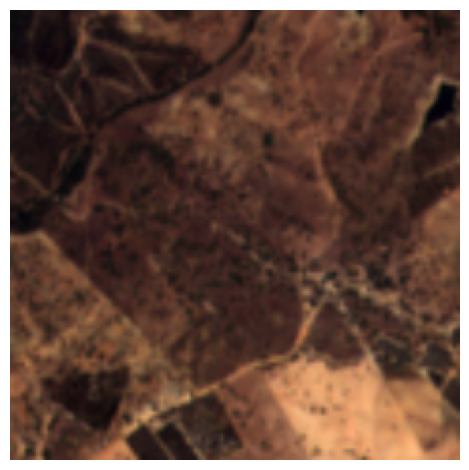

In [32]:
torchshow.show(img)

In [35]:
df = reader.metadata_parquet.loc[reader.metadata_parquet['patch_id'].isin(dataset_val.patch_ids_array)]

In [48]:
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np
mlb = MultiLabelBinarizer()
labels_matrix = mlb.fit_transform(df['labels'])
        
        ## Convert to df
labels_df = pd.DataFrame(labels_matrix, columns = mlb.classes_)

## Sum classes
df_sum = pd.DataFrame()
df_sum['sum'] = labels_df.sum(0).values
##df_sum.sort_values(by='labels',inplace=True)  ##MAKE IT SURE IS IN ORDER.
df_sum['num_negatives'] = (labels_df.T.sum(1).sum()- labels_df.T.sum(1)).values
df_sum['neg/pos'] = df_sum['num_negatives']/df_sum['sum']

## apply square root of log to use as the weights
#df_sum["logs"] = np.sqrt(np.log(df_sum["neg/pos"].values + 1)) 
df_sum["logs"] = np.log(df_sum["neg/pos"].values + 1) 

In [43]:
df_sum

,sum,num_negatives,neg/pos,logs
0,7156,243193,33.984489,3.554905
1,28315,222034,7.841568,2.179464
2,297,250052,841.925926,6.736879
3,23144,227205,9.817015,2.381120
4,244,250105,1025.020492,6.933443
5,19104,231245,12.104533,2.572958
6,22419,227930,10.166823,2.412947
7,5935,244414,41.181803,3.741989
8,10701,239648,22.394916,3.152519
9,6916,243433,35.198525,3.589018


In [60]:
labels_df[labels_df['Urban fabric']==1].index[:10]

Index([22, 35, 49, 83, 84, 107, 115, 122, 132, 182], dtype='int64')

2025-08-19 11:43:48.010 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:43:48.015 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:43:48.019 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:43:48.023 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:43:48.027 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:43:48.030 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:43:48.034 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:43:48.037 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04'

2025-08-19 11:43:48.055 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:43:48.059 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:43:48.064 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:43:48.067 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:43:48.071 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:43:48.074 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:43:48.078 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:43:48.081 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04'

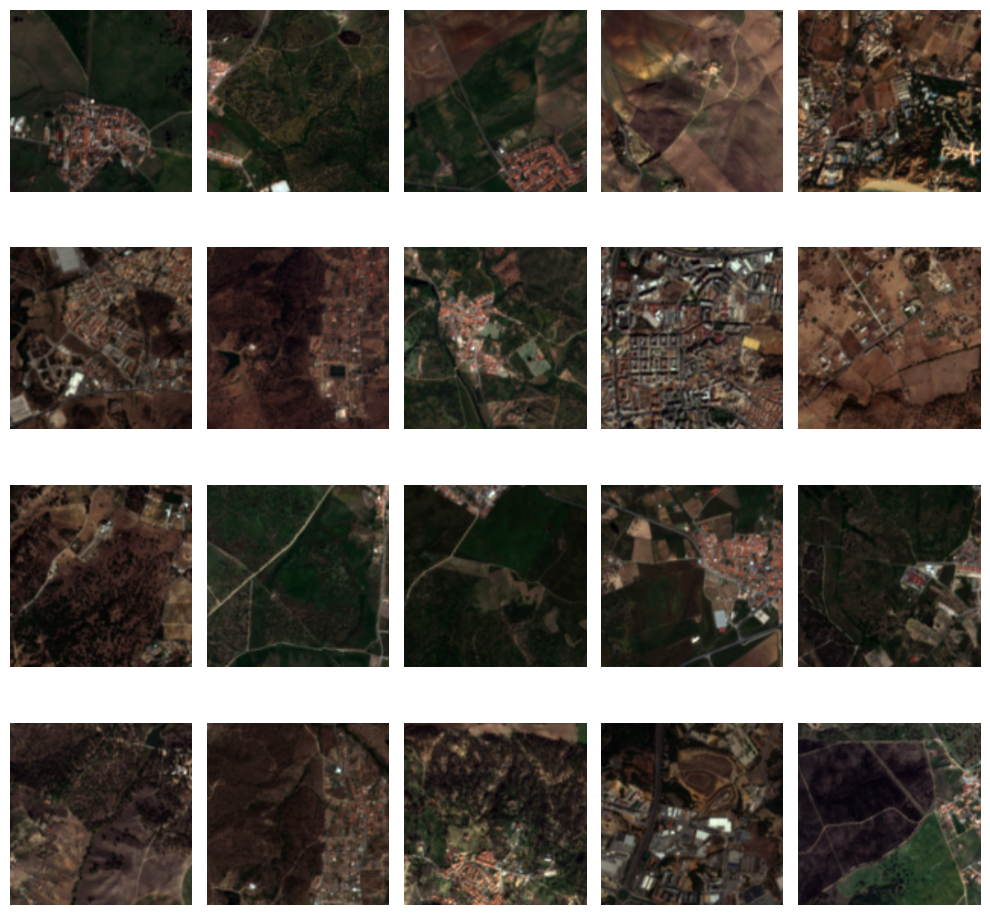

In [70]:
list_img=[]
for i in labels_df[labels_df['Urban fabric']==1].index[:20]:
    img, label, patch = dataset_val.__getitem__(i)
    list_img.append(img)
torchshow.show(list_img, ncols=5, figsize=(10, 10))

2025-08-19 11:47:16.548 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:47:16.563 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:47:16.569 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:47:16.573 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:47:16.577 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:47:16.584 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:47:16.598 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 11:47:16.602 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04'

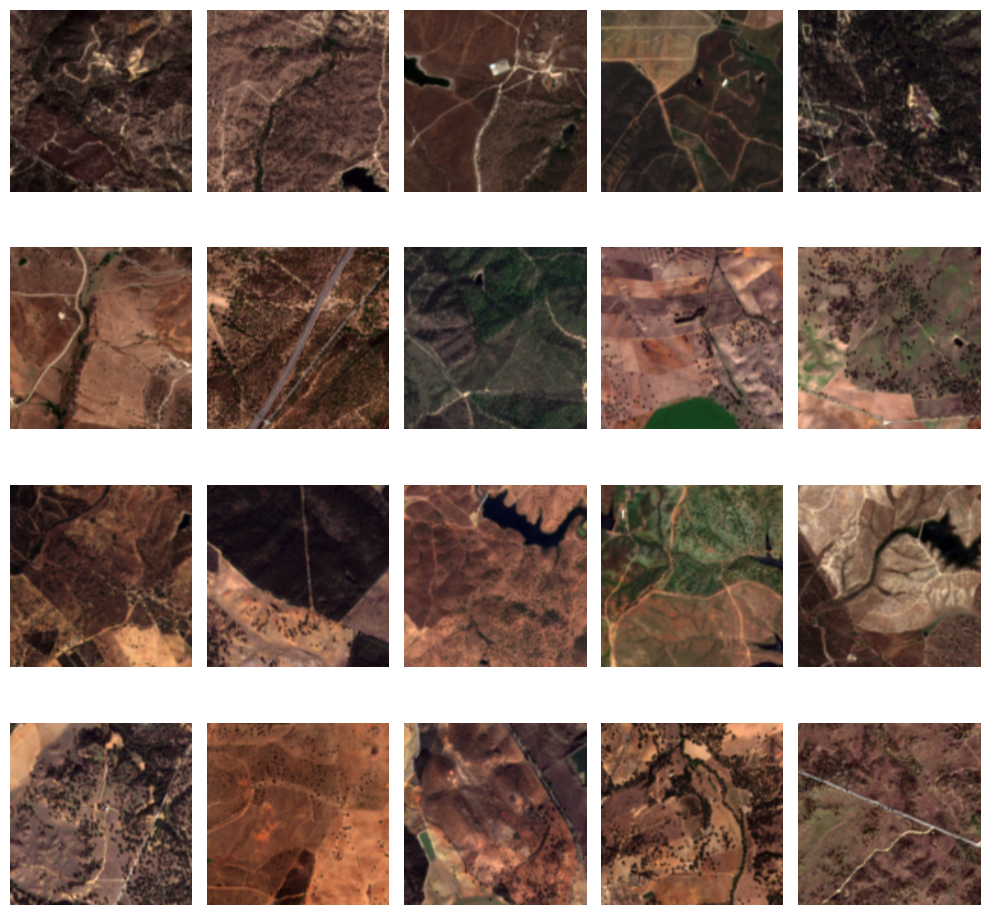

In [ ]:
list_img=[]
list_labels = []
for i in labels_df.index[:20]:
    img, label, patch = dataset_val.__getitem__(i)
    list_img.append(img)
    list_labels.append(label)
torchshow.show(list_img, ncols=5, figsize=(10, 10))




In [109]:
import numpy as np
def get_label_back(array_label):
    idx_to_label= {0: 'Agro-forestry areas',
                    1: 'Arable land',
                    2: 'Beaches, dunes, sands',
                    3: 'Broad-leaved forest',
                    4: 'Coastal wetlands',
                    5: 'Complex cultivation patterns',
                    6: 'Coniferous forest',
                    7: 'Industrial or commercial units',
                    8: 'Inland waters',
                    9: 'Inland wetlands',
                    10: 'Land principally occupied by agriculture, with significant areas of natural vegetation',
                    11: 'Marine waters',
                    12: 'Mixed forest',
                    13: 'Moors, heathland and sclerophyllous vegetation',
                    14: 'Natural grassland and sparsely vegetated areas',
                    15: 'Pastures',
                    16: 'Permanent crops',
                    17: 'Transitional woodland, shrub',
                    18: 'Urban fabric'}
    label_list = []
    for i,pos in enumerate(array_label):
        if int(pos)==1:
            label_list.append(idx_to_label[i])
    return label_list


def plot_list_of_imgs(list_of_img, list_of_labels, ncols=4, figsize=(15, 10)):
    """
    Plot images from a batch with their corresponding labels.
    
    Args:
        batch: Tuple of (images, labels) from dataloader
        num_samples: Number of samples to display (default: 8)
        figsize: Figure size for the plot (default: (15, 10))
    """
    images= list_img
    labels = list_of_labels
    
    rows = int(len(images)/ncols)-1
    cols = ncols
    num_samples = int(len(images))

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    
    for idx in range(num_samples):
        row = idx // rows
        col = idx % cols
        ax = axes[row, col]
        
        if idx < len(images):
            # Handle image data
            img = images[idx].numpy()
            
            imgm =  np.transpose(img, (2,1,0))

            # Normalize to 0-1 range for display
            imgm_normalized = (imgm - imgm.min()) / (imgm.max() - imgm.min())

            #ax.imshow(imgm)
            ax.imshow(imgm_normalized)
            # Get and display labels
            label_array = labels[idx]
            label_names = get_label_back(label_array.numpy())
            
            # Format labels for display
            if len(label_names) > 1:
                title = f"{'\n'.join(label_names)}"
            else:
                title = ', '.join(label_names)
            
            ax.set_title(title, fontsize=8, wrap=True)
            ax.axis('off')
        else:
            # Hide empty subplots
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

In [ ]:
'\n '.join(get_label_back(label.numpy()))

'Agro-forestry areas\nBroad-leaved forest\nTransitional woodland, shrub'

IndexError: index 4 is out of bounds for axis 0 with size 4

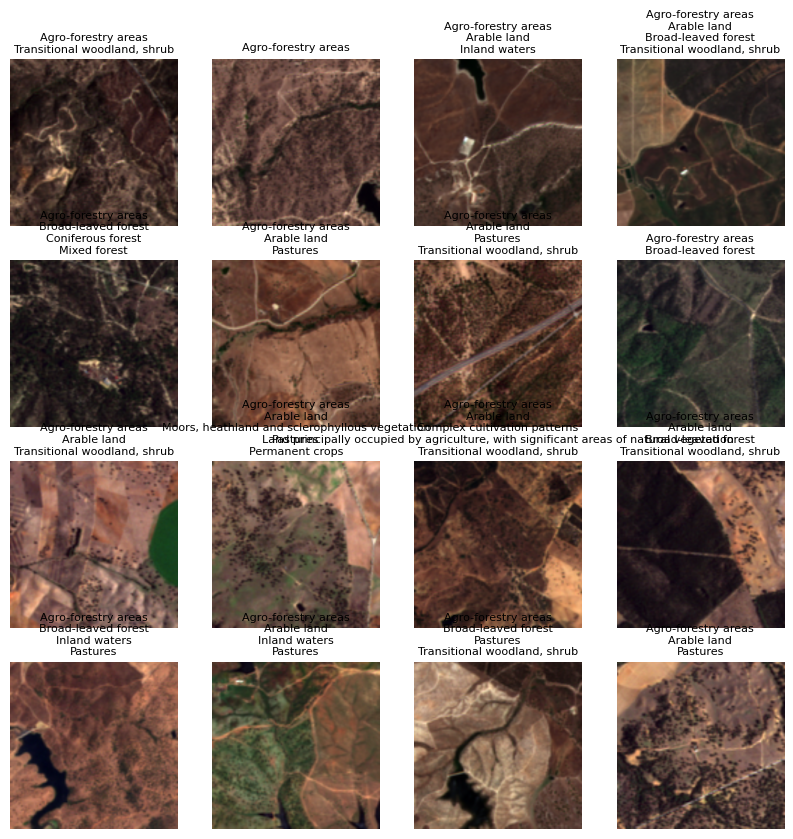

In [110]:
plot_list_of_imgs(list_img, list_labels, ncols=4, figsize=(10, 10))

2025-08-19 12:18:56.015 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 12:18:56.053 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 12:18:56.089 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 12:18:56.125 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 12:18:56.161 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 12:18:56.199 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 12:18:56.235 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04', 'B03', 'B02']
2025-08-19 12:18:56.270 | INFO     | src.loader.reader:stack_and_interpolate:575 - Using order of bands: ['B04'

IndexError: index 4 is out of bounds for axis 0 with size 4

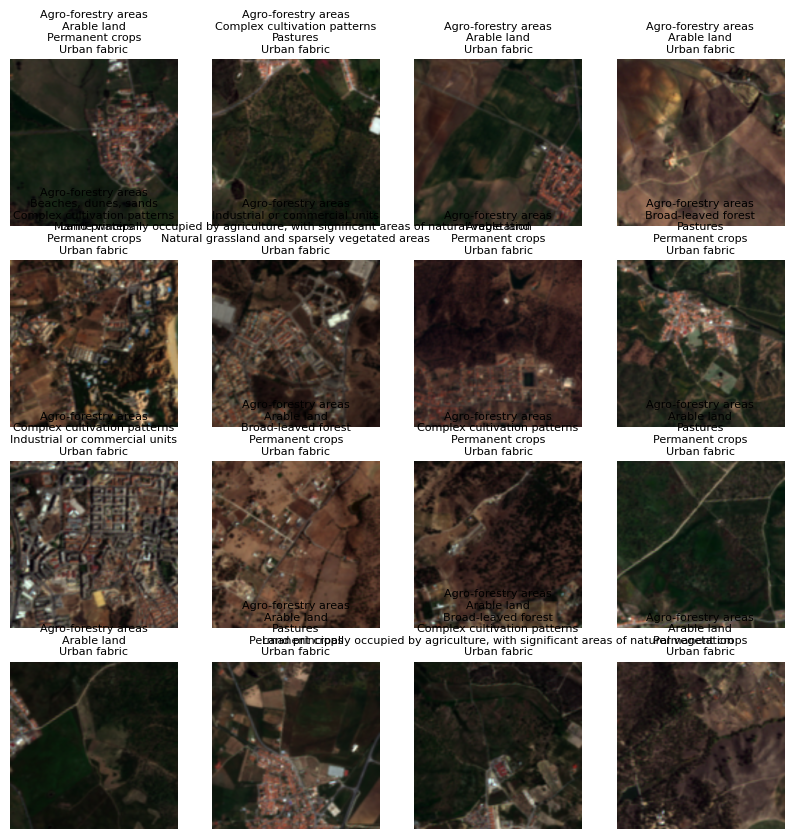

In [112]:

list_img=[]
list_labels = []
for i in labels_df[labels_df['Urban fabric']==1].index[:20]:
    img, label, patch = dataset_val.__getitem__(i)
    list_img.append(img)
    list_labels.append(label)
plot_list_of_imgs(list_img, list_labels, ncols=4, figsize=(10, 10))


In [114]:
t = dataset_val.calculate_unbalanced_df()

2025-08-19 12:31:46.576 | INFO     | src.loader.reader:calculate_unbalanced_df:533 - Value of imbalanced before clip: [3.55490478 2.17946424 6.73687908 2.38112038 6.933443   2.57295821
 2.41294713 3.74198892 3.15251875 3.58901838 2.44241494 3.6066689
 2.34872647 3.87362056 3.70672912 2.78686637 3.37575575 2.37298728
 2.81613997]
2025-08-19 12:31:46.578 | WARNING  | src.loader.reader:calculate_unbalanced_df:542 - Unbalanced results: [3 1 7 1 8 1 1 3 2 3 1 3 1 3 3 1 2 1 1]


---------------------------------------------
Agro-forestry areas : 3
Arable land : 1
Beaches, dunes, sands : 7
Broad-leaved forest : 1
Coastal wetlands : 8
Complex cultivation patterns : 1
Coniferous forest : 1
Industrial or commercial units : 3
Inland waters : 2
Inland wetlands : 3
Land principally occupied by agriculture, with significant areas of natural vegetation : 1
Marine waters : 3
Mixed forest : 1
Moors, heathland and sclerophyllous vegetation : 3
Natural grassland and sparsely vegetated areas : 3
Pastures : 1
Permanent crops : 2
Transitional woodland, shrub : 1
Urban fabric : 1


In [117]:
tt = t.numpy()+1

In [ ]:
tt[-1]

array([4, 2, 8, 2, 9, 2, 2, 4, 3, 4, 2, 4, 2, 4, 4, 2, 3, 2, 2])

In [120]:
print(dataset_val.mlb_labels_)

None


In [121]:
dataset_val.mlb

,classes,None
,sparse_output,False


In [122]:
dataset_val.mlb.classes_

array(['Agro-forestry areas', 'Arable land', 'Beaches, dunes, sands',
       'Broad-leaved forest', 'Coastal wetlands',
       'Complex cultivation patterns', 'Coniferous forest',
       'Industrial or commercial units', 'Inland waters',
       'Inland wetlands',
       'Land principally occupied by agriculture, with significant areas of natural vegetation',
       'Marine waters', 'Mixed forest',
       'Moors, heathland and sclerophyllous vegetation',
       'Natural grassland and sparsely vegetated areas', 'Pastures',
       'Permanent crops', 'Transitional woodland, shrub', 'Urban fabric'],
      dtype=object)

In [124]:
len(dataset_val.mlb.classes_)

19

In [126]:
arr = MultiLabelBinarizer().fit(reader.metadata_parquet['labels'].values).classes_

In [132]:

dict_one_hot = {v:i for i,v in enumerate(arr)}
idx_to_label = {i:v for i,v in enumerate(arr)}

In [133]:
idx_to_label

{0: 'Agro-forestry areas',
 1: 'Arable land',
 2: 'Beaches, dunes, sands',
 3: 'Broad-leaved forest',
 4: 'Coastal wetlands',
 5: 'Complex cultivation patterns',
 6: 'Coniferous forest',
 7: 'Industrial or commercial units',
 8: 'Inland waters',
 9: 'Inland wetlands',
 10: 'Land principally occupied by agriculture, with significant areas of natural vegetation',
 11: 'Marine waters',
 12: 'Mixed forest',
 13: 'Moors, heathland and sclerophyllous vegetation',
 14: 'Natural grassland and sparsely vegetated areas',
 15: 'Pastures',
 16: 'Permanent crops',
 17: 'Transitional woodland, shrub',
 18: 'Urban fabric'}

In [130]:
idx_to_label= {v:i for dict_one_hot.items()}

SyntaxError: cannot assign to function call (1949634572.py, line 1)

In [131]:
dict_one_hot.items()

dict_items([('Agro-forestry areas', 0), ('Arable land', 1), ('Beaches, dunes, sands', 2), ('Broad-leaved forest', 3), ('Coastal wetlands', 4), ('Complex cultivation patterns', 5), ('Coniferous forest', 6), ('Industrial or commercial units', 7), ('Inland waters', 8), ('Inland wetlands', 9), ('Land principally occupied by agriculture, with significant areas of natural vegetation', 10), ('Marine waters', 11), ('Mixed forest', 12), ('Moors, heathland and sclerophyllous vegetation', 13), ('Natural grassland and sparsely vegetated areas', 14), ('Pastures', 15), ('Permanent crops', 16), ('Transitional woodland, shrub', 17), ('Urban fabric', 18)])